In [28]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv')

for col in df.columns:
    print(col) 

Date of Surgery
Sex
Age
LLIF?
Case/Type of Surgery
Perc screws?
Open
Open Check V2
Standalone XLIF Check
 Retroperitoneal Approach (LLIF ± ALIF)
Anterior + Posterior Apporoach
Osteotomies (yes/no)
osteotomy level
T12-L1
L1-L2
L2-L3
L3-L4
L4-L5
L5-S1
ALIF Count
Lateral Count
ACR (y=1)
ACR level
Additional Procedures w/in surgery
Pre op Diagnosis (back pain, adjacent segment disease, spondy)
BMI
prior back surgeries? (y=1)
Average PI
VALIDATION COLUMN
PI-LL angle mismatch
ABS PI-LL angle mismatch
PI-LL Mismatch Category (1 = mismatch > +/- 9
PI-LL Mismatch Category (1 = mismatch > +/- 10
(1 = PI>50)
Post-op SS
Post-op SS Grouping
Roussouly Class
post PI
post PT
post LL
post SVA
post-op date
most recent PI
most recent PT
most recent LL
most recent SVA
most recent date
subsidence 
titanium v PEEK (T=0,P=1)
cage details
length of hospital stay (d)
post op complications? (Y/N)
infection 1=yes
DVT  1=yes
PE  1=yes
MI 1=yes
infection 
DVT
PE
MI
Hernia
Hematoma
femoral palsy (knee extension wea

In [ ]:
clean_feature_cols = [

    # Demographics
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # Pre-op diagnosis
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",

    # Case type
    "Case/Type of Surgery",
    "Additional Procedures w/in surgery",

    # Fusion levels
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Surgical approach / technique
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Preoperative spinopelvic parameters
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",

    # Immediate postoperative alignment (allowed)
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # Immediate postop complications (allowed)
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # Hospital course
    "length of hospital stay (d)",
]


In [30]:
import pandas as pd
import numpy as np
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

time_col = "Time Until ASD Diagnosis (months)"


C:\Users\SBSBB\AppData\Local\Temp\ipykernel_35908\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\SBSBB\AppData\Local\Temp\ipykernel_35908\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\SBSBB\AppData\Local\Temp\ipykernel_35908\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")


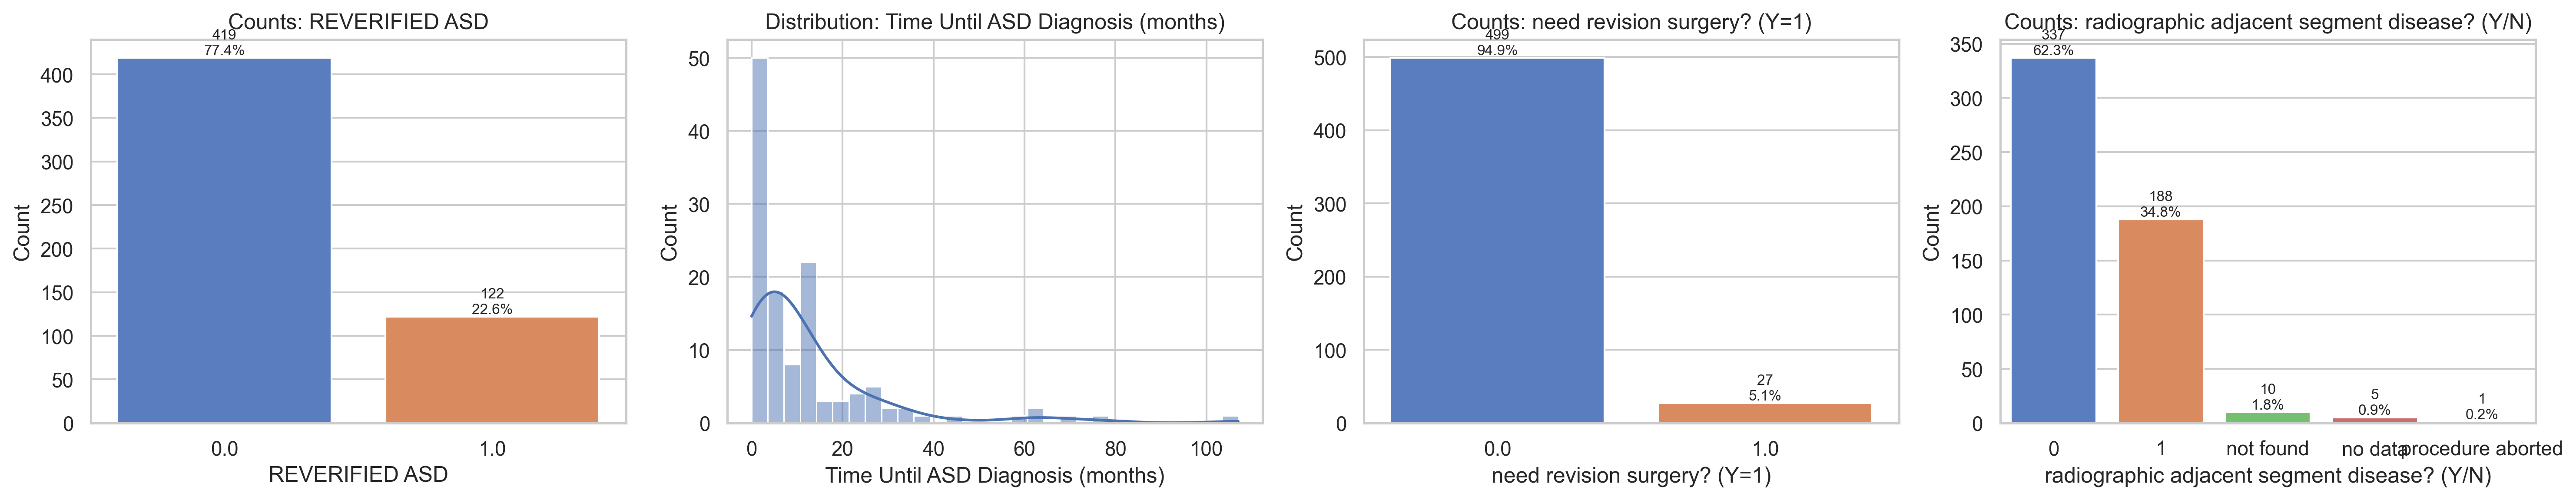

In [31]:
import seaborn as sns
from pandas.api import types as pd_types

import matplotlib.pyplot as plt

# helper to find column with case-insensitive / partial matching
def find_col(df, name):
    name_l = name.lower()
    # exact lower match
    for c in df.columns:
        if c.lower() == name_l:
            return c
    # substring match
    for c in df.columns:
        if name_l in c.lower() or c.lower() in name_l:
            return c
    return None

# desired columns (use existing notebook variables where available)
cols_wanted = [
    "REVERIFIED ASD",                    # user: 'Reverified ASD'
    time_col,                            # 'Time Until ASD Diagnosis (months)' (variable from notebook)
    "need revision surgery? (Y=1)",      # user-provided name
    "radiographic adjacent segment disease? (Y/N)"
]

# resolve to actual df columns, skip missing
cols = []
for nm in cols_wanted:
    c = find_col(df, nm)
    if c is None:
        print(f"Column not found (skipping): {nm}")
    else:
        cols.append(c)

if not cols:
    raise RuntimeError("No plotting columns found in df.")

sns.set(style="whitegrid")

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=300, squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    series = df[col].dropna()
    # decide continuous vs categorical/binary
    is_numeric = pd_types.is_numeric_dtype(series.dtype)
    unique_vals = series.nunique(dropna=True)
    if is_numeric and unique_vals > 10:
        # distribution for continuous
        sns.histplot(series.astype(float), kde=True, bins=30, ax=ax, color="C0")
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:
        # histogram / countplot for categorical / binary
        order = series.value_counts(dropna=True).index
        sns.countplot(x=series, order=order, ax=ax, palette="muted")
        ax.set_title(f"Counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        # annotate counts / percentages
        totals = len(series)
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            pct = 100 * height / totals
            ax.annotate(f"{int(height)}\n{pct:.1f}%", (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd


# 2. Clean column names a bit
df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

df.columns



Index(['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery',
       'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check',
       'Retroperitoneal Approach (LLIF ± ALIF)',
       ...
       'alif_text', 'dx_adjacent_segment', 'dx_spondylolisthesis',
       'dx_spondylosis', 'dx_stenosis', 'dx_scoliosis', 'dx_flat_back',
       'dx_sagittal_imbalance', 'dx_post_laminectomy', 'dx_deformity'],
      dtype='object', length=116)

In [33]:
target = "Time Until ASD Diagnosis (months)"

# Keep only rows where the target is known (patients who actually developed ASD)
asd_df = df[df[target].notna()].copy()
asd_df.shape


(125, 116)

In [49]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN

# ---------------------------
# 1. Define columns & label
# ---------------------------

# Make sure df already loaded and columns cleaned as you showed earlier

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

# 1a. Build full survival labels: time + event for ALL patients
df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing
# ---------------------------------

X = df_surv[clean_feature_cols].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

# 2c. Train/test split
X_train, X_test, durations_train, durations_test, events_train, events_test = train_test_split(
    X_encoded.values,
    durations_all,
    events_all,
    test_size=0.2,
    random_state=42,
)

# Standardize for DeepSurv (not strictly needed for Cox/RSF/GBSA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# ---------------------------------
# 3. Classical Survival Models
# ---------------------------------

# Build sksurv y object
y_train = Surv.from_arrays(event=events_train, time=durations_train)
y_test = Surv.from_arrays(event=events_test, time=durations_test)

models = {
    "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
    "rsf": RandomSurvivalForest(
        n_estimators=300,
        min_samples_split=10,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42,
    ),
    "gbsa": GradientBoostingSurvivalAnalysis(
        learning_rate=0.05,
        max_depth=3,
        n_estimators=300,
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        ci = concordance_index_censored(
            events_test,
            durations_test,
            pred
        )[0]
        results.append((name, ci))
    except LinAlgError:
        print(f"Skipping {name}: singular matrix.")

print("\n=== Classical Survival Models (Full Cohort) ===")
for name, ci in results:
    print(f"{name}: C-index = {ci:.3f}")

# ---------------------------------
# 4. DeepSurv (Cox neural net)
# ---------------------------------

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN
from sksurv.metrics import concordance_index_censored

# 1. Small, heavily-regularized net
in_features = X_train_scaled.shape[1]
num_nodes = [8, 8]
out_features = 1
dropout = 0.3

net = tt.practical.MLPVanilla(
    in_features,
    num_nodes,
    out_features,
    batch_norm=True,
    dropout=dropout,
)

optimizer = tt.optim.Adam(lr=1e-4, weight_decay=1e-2)  # smaller lr, stronger L2

ds_model = CoxPH_NN(net, optimizer)

durations_train_float = durations_train.astype("float32")
events_train_bool = events_train.astype(bool)
y_train_nn = (durations_train_float, events_train_bool)

batch_size = 64
epochs = 5000

_ = ds_model.fit(
    X_train_scaled.astype("float32"),
    y_train_nn,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
)

# 2. Evaluate with NaN checking
durations_test_float = durations_test.astype("float32")
events_test_bool = events_test.astype(bool)
X_test_scaled_f32 = X_test_scaled.astype("float32")

risk_scores_test = ds_model.predict(X_test_scaled_f32).reshape(-1).astype(float)

print("NaNs in DeepSurv predictions:", np.isnan(risk_scores_test).sum())

mask = ~np.isnan(risk_scores_test)

if mask.sum() > 0:
    ci_ds = concordance_index_censored(
        events_test_bool[mask],
        durations_test_float[mask],
        risk_scores_test[mask]
    )[0]
    print("\n=== DeepSurv (Full Cohort, conservative) ===")
    print(f"DeepSurv C-index = {ci_ds:.3f}")
    print("Test used for C-index:", mask.sum(), "of", len(risk_scores_test))
else:
    print("\nDeepSurv still produced all-NaN predictions; using RSF as primary model.")


Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['Additional Procedures w/in surgery', 'osteotomy level', 'ACR level']
Train shape: (436, 128)  Test shape: (110, 128)

=== Classical Survival Models (Full Cohort) ===
coxph: C-index = 0.569
rsf: C-index = 0.593
gbsa: C-index = 0.583
0:	[0s / 0s],		train_loss: 3.4639
1:	[0s / 0s],		train_loss: 3.4566
2:	[0s / 0s],		train_loss: 3.4096
3:	[0s / 0s],		train_loss: 3.4625
4:	[0s / 0s],		train_loss: 3.4787
5:	[0s / 0s],		train_loss: 3.4967
6:	[0s / 0s],		train_loss: 3.8036
7:	[0s / 0s],		train_loss: 3.4272
8:	[0s / 0s],		train_loss: 3.4207
9:	[0s / 0s],		train_loss: 3.4868
10:	[0s / 0s],		train_loss: 3.4955
11:	[0s / 0s],		train_loss: 3.4358
12:	[0s / 0s],		train_loss: 3.3774
13:	[0s / 0s],		train_loss: 3.4563
14:	[0s / 0s],		train_loss: 3.4007
15:	[0s / 0s],		train_loss: 3.4239
16:	[0s / 0s],		train_loss: 3.3856
17:	[0s / 0s],		train_loss: 3.4656
18:	[0s / 0s],		train_loss: 3.4562
19:	[0s / 0s],		t

In [56]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN

# ---------------------------
# 1. Define columns & labels
# ---------------------------

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

# df is assumed to be your cleaned dataframe (e.g. df_lace or df_clean)

df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing
# ---------------------------------

X = df_surv[clean_feature_cols].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Simple imputation: fill remaining NaNs
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Final feature matrix shape:", X_encoded.shape)

# ---------------------------------
# 3. Cross-validated classical survival models
# ---------------------------------

# Define models (we'll re-instantiate them inside each fold)
def build_models():
    return {
        "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
        "rsf": RandomSurvivalForest(
            n_estimators=300,
            min_samples_split=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42,
        ),
        "gbsa": GradientBoostingSurvivalAnalysis(
            learning_rate=0.05,
            max_depth=3,
            n_estimators=300,
            random_state=42,
        ),
    }

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = {name: [] for name in build_models().keys()}
cv_results_deepsurv = []

X_values = X_encoded.values

fold_idx = 1

for train_idx, test_idx in skf.split(X_values, events_all):
    print(f"\n===== Fold {fold_idx}/{n_splits} =====")
    fold_idx += 1

    X_train = X_values[train_idx]
    X_test = X_values[test_idx]
    durations_train = durations_all[train_idx]
    durations_test = durations_all[test_idx]
    events_train = events_all[train_idx]
    events_test = events_all[test_idx]

    # Build sksurv Surv objects
    y_train = Surv.from_arrays(event=events_train, time=durations_train)
    y_test = Surv.from_arrays(event=events_test, time=durations_test)

    # ------------------
    # Classical models
    # ------------------
    models = build_models()

    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            ci = concordance_index_censored(
                events_test,
                durations_test,
                pred
            )[0]
            cv_results[name].append(ci)
            print(f"{name} C-index (fold): {ci:.3f}")
        except LinAlgError:
            print(f"Skipping {name} in this fold: singular matrix.")
            cv_results[name].append(np.nan)

    # ------------------
    # DeepSurv in CV
    # ------------------

    # Standardize for DeepSurv
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    in_features = X_train_scaled.shape[1]
    num_nodes = [8, 8]
    out_features = 1
    dropout = 0.3

    net = tt.practical.MLPVanilla(
        in_features,
        num_nodes,
        out_features,
        batch_norm=True,
        dropout=dropout,
    )

    optimizer = tt.optim.Adam(lr=1e-4, weight_decay=1e-2)  # strong L2
    ds_model = CoxPH_NN(net, optimizer)

    durations_train_float = durations_train.astype("float32")
    events_train_bool = events_train.astype(bool)
    y_train_nn = (durations_train_float, events_train_bool)

    batch_size = 64
    epochs = 1000  # you can increase, but 5000 * 5 folds is huge

    _ = ds_model.fit(
        X_train_scaled.astype("float32"),
        y_train_nn,
        batch_size=batch_size,
        epochs=epochs,
        verbose=False,
    )

    durations_test_float = durations_test.astype("float32")
    events_test_bool = events_test.astype(bool)
    X_test_scaled_f32 = X_test_scaled.astype("float32")

    risk_scores_test = ds_model.predict(X_test_scaled_f32).reshape(-1).astype(float)
    n_nans = np.isnan(risk_scores_test).sum()
    print("DeepSurv NaNs in predictions (this fold):", n_nans)

    mask = ~np.isnan(risk_scores_test)

    if mask.sum() > 0:
        ci_ds = concordance_index_censored(
            events_test_bool[mask],
            durations_test_float[mask],
            risk_scores_test[mask]
        )[0]
        cv_results_deepsurv.append(ci_ds)
        print(f"DeepSurv C-index (fold): {ci_ds:.3f}")
    else:
        cv_results_deepsurv.append(np.nan)
        print("DeepSurv produced all-NaN predictions in this fold.")

# ---------------------------------
# 4. Summarize CV results
# ---------------------------------

print("\n===== Cross-validated C-index (mean ± SD) =====")
for name, scores in cv_results.items():
    scores_arr = np.array(scores, dtype=float)
    mean_ci = np.nanmean(scores_arr)
    std_ci = np.nanstd(scores_arr)
    print(f"{name}: {mean_ci:.3f} ± {std_ci:.3f} over {n_splits} folds")

if len(cv_results_deepsurv) > 0:
    ds_arr = np.array(cv_results_deepsurv, dtype=float)
    mean_ci_ds = np.nanmean(ds_arr)
    std_ci_ds = np.nanstd(ds_arr)
    print(f"DeepSurv: {mean_ci_ds:.3f} ± {std_ci_ds:.3f} over {n_splits} folds")


Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['Additional Procedures w/in surgery', 'osteotomy level', 'ACR level']
Final feature matrix shape: (546, 128)

===== Fold 1/5 =====
coxph C-index (fold): 0.511
rsf C-index (fold): 0.460
gbsa C-index (fold): 0.499
DeepSurv NaNs in predictions (this fold): 0
DeepSurv C-index (fold): 0.417

===== Fold 2/5 =====
coxph C-index (fold): 0.559
rsf C-index (fold): 0.618
gbsa C-index (fold): 0.599
DeepSurv NaNs in predictions (this fold): 0
DeepSurv C-index (fold): 0.536

===== Fold 3/5 =====
coxph C-index (fold): 0.592
rsf C-index (fold): 0.621
gbsa C-index (fold): 0.624
DeepSurv NaNs in predictions (this fold): 0
DeepSurv C-index (fold): 0.525

===== Fold 4/5 =====
coxph C-index (fold): 0.618
rsf C-index (fold): 0.676
gbsa C-index (fold): 0.657
DeepSurv NaNs in predictions (this fold): 0
DeepSurv C-index (fold): 0.591

===== Fold 5/5 =====
coxph C-index (fold): 0.573
rsf C-index (fold): 0.608
gbsa C-i

In [39]:
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
import scipy.integrate

# Patch simps → simpson for compatibility with pycox
if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson


# Choose number of time bins (you can tune this)
num_durations = 20

labtrans = LabTransDiscreteTime(num_durations)
y_train_disc = labtrans.fit_transform(durations_train, events_train)
y_test_disc = labtrans.transform(durations_test, events_test)

# y_train_disc is (discrete_time_index, event)
idx_durations_train, events_train_disc = y_train_disc
idx_durations_test, events_test_disc = y_test_disc

# duration index (actual time grid for bins)
duration_index = labtrans.cuts
print("Discrete-time duration_index:", duration_index.shape)

from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv

in_features = X_train_scaled.shape[1]
num_nodes = [64, 64]
out_features = num_durations  # PMF over time
dropout = 0.2

net = tt.practical.MLPVanilla(
    in_features,
    num_nodes,
    out_features,
    batch_norm=True,
    dropout=dropout,
)

optimizer = tt.optim.Adam(lr=1e-3)

dh_model = DeepHitSingle(
    net,
    optimizer,
    alpha=0.2,   # weight for ranking loss
    sigma=0.1,   # smoothing of PMF
    duration_index=duration_index,
)

batch_size = 64
epochs = 200

_ = dh_model.fit(
    X_train_scaled.astype('float32'),
    (idx_durations_train, events_train_disc),
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
)

# Predict survival for test set
surv_dh = dh_model.predict_surv_df(X_test_scaled.astype('float32'))

ev_dh = EvalSurv(surv_dh, durations_test, events_test, censor_surv='km')
c_index_dh = ev_dh.concordance_td()
ibs_dh = ev_dh.integrated_brier_score(duration_index)

print("\n=== DeepHitSingle (Discrete-time) ===")
print(f"C-index (td) = {c_index_dh:.3f}")
print(f"Integrated Brier Score (IBS) = {ibs_dh:.4f}")


Discrete-time duration_index: (20,)
0:	[0s / 0s],		train_loss: 0.2824
1:	[0s / 0s],		train_loss: 0.2623
2:	[0s / 0s],		train_loss: 0.2673
3:	[0s / 0s],		train_loss: 0.2556
4:	[0s / 0s],		train_loss: 0.2424
5:	[0s / 0s],		train_loss: 0.2376
6:	[0s / 0s],		train_loss: 0.2378
7:	[0s / 0s],		train_loss: 0.2339
8:	[0s / 0s],		train_loss: 0.2270
9:	[0s / 0s],		train_loss: 0.2215
10:	[0s / 0s],		train_loss: 0.2163
11:	[0s / 0s],		train_loss: 0.2132
12:	[0s / 0s],		train_loss: 0.2110
13:	[0s / 0s],		train_loss: 0.2067
14:	[0s / 0s],		train_loss: 0.1995
15:	[0s / 0s],		train_loss: 0.1977
16:	[0s / 0s],		train_loss: 0.1963
17:	[0s / 0s],		train_loss: 0.1856
18:	[0s / 0s],		train_loss: 0.1888
19:	[0s / 0s],		train_loss: 0.1718
20:	[0s / 0s],		train_loss: 0.1769
21:	[0s / 0s],		train_loss: 0.1707
22:	[0s / 0s],		train_loss: 0.1624
23:	[0s / 0s],		train_loss: 0.1650
24:	[0s / 0s],		train_loss: 0.1592
25:	[0s / 0s],		train_loss: 0.1583
26:	[0s / 0s],		train_loss: 0.1517
27:	[0s / 0s],		train_loss: 0

In [40]:
from pycox.models import MTLR

in_features = X_train_scaled.shape[1]
num_nodes = [32, 32]
out_features = num_durations
dropout = 0.2

net = tt.practical.MLPVanilla(
    in_features,
    num_nodes,
    out_features,
    batch_norm=True,
    dropout=dropout,
)

optimizer = tt.optim.Adam(lr=1e-3)

mtlr_model = MTLR(
    net,
    optimizer,
    duration_index=duration_index,
)

_ = mtlr_model.fit(
    X_train_scaled.astype('float32'),
    (idx_durations_train, events_train_disc),
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
)

surv_mtlr = mtlr_model.predict_surv_df(X_test_scaled.astype('float32'))

ev_mtlr = EvalSurv(surv_mtlr, durations_test, events_test, censor_surv='km')
c_index_mtlr = ev_mtlr.concordance_td()
ibs_mtlr = ev_mtlr.integrated_brier_score(duration_index)

print("\n=== N-MTLR (Discrete-time) ===")
print(f"C-index (td) = {c_index_mtlr:.3f}")
print(f"Integrated Brier Score (IBS) = {ibs_mtlr:.4f}")


0:	[0s / 0s],		train_loss: 1.0410
1:	[0s / 0s],		train_loss: 1.0538
2:	[0s / 0s],		train_loss: 0.9670
3:	[0s / 0s],		train_loss: 0.9291
4:	[0s / 0s],		train_loss: 0.8979
5:	[0s / 0s],		train_loss: 0.8417
6:	[0s / 0s],		train_loss: 0.8387
7:	[0s / 0s],		train_loss: 0.8126
8:	[0s / 0s],		train_loss: 0.8489
9:	[0s / 0s],		train_loss: 0.8094
10:	[0s / 0s],		train_loss: 0.8247
11:	[0s / 0s],		train_loss: 0.8023
12:	[0s / 0s],		train_loss: 0.7857
13:	[0s / 0s],		train_loss: 0.7622
14:	[0s / 0s],		train_loss: 0.7639
15:	[0s / 0s],		train_loss: 0.7440
16:	[0s / 0s],		train_loss: 0.7351
17:	[0s / 0s],		train_loss: 0.7336
18:	[0s / 0s],		train_loss: 0.7274
19:	[0s / 0s],		train_loss: 0.7244
20:	[0s / 0s],		train_loss: 0.7339
21:	[0s / 0s],		train_loss: 0.7049
22:	[0s / 0s],		train_loss: 0.6859
23:	[0s / 0s],		train_loss: 0.6838
24:	[0s / 0s],		train_loss: 0.6933
25:	[0s / 0s],		train_loss: 0.6811
26:	[0s / 0s],		train_loss: 0.6832
27:	[0s / 0s],		train_loss: 0.6656
28:	[0s / 0s],		train_loss: 0.

In [37]:
from pycox.models import BCESurv

in_features = X_train_scaled.shape[1]
num_nodes = [32, 32]
out_features = num_durations
dropout = 0.2

net = tt.practical.MLPVanilla(
    in_features,
    num_nodes,
    out_features,
    batch_norm=True,
    dropout=dropout,
)

optimizer = tt.optim.Adam(lr=1e-3)

bce_model = BCESurv(
    net,
    optimizer,
    duration_index=duration_index,
)

_ = bce_model.fit(
    X_train_scaled.astype('float32'),
    (idx_durations_train, events_train_disc),
    batch_size=batch_size,
    epochs=epochs,
    verbose=True,
)

surv_bce = bce_model.predict_surv_df(X_test_scaled.astype('float32'))

ev_bce = EvalSurv(surv_bce, durations_test, events_test, censor_surv='km')
c_index_bce = ev_bce.concordance_td()
ibs_bce = ev_bce.integrated_brier_score(duration_index)

print("\n=== BCESurv (Discrete-time) ===")
print(f"C-index (td) = {c_index_bce:.3f}")
print(f"Integrated Brier Score (IBS) = {ibs_bce:.4f}")


0:	[0s / 0s],		train_loss: 0.2469
1:	[0s / 0s],		train_loss: 0.2437
2:	[0s / 0s],		train_loss: 0.2388
3:	[0s / 0s],		train_loss: 0.2313
4:	[0s / 0s],		train_loss: 0.2315
5:	[0s / 0s],		train_loss: 0.2262
6:	[0s / 0s],		train_loss: 0.2242
7:	[0s / 0s],		train_loss: 0.2258
8:	[0s / 0s],		train_loss: 0.2182
9:	[0s / 0s],		train_loss: 0.2134
10:	[0s / 0s],		train_loss: 0.2092
11:	[0s / 0s],		train_loss: 0.2039
12:	[0s / 0s],		train_loss: 0.2013
13:	[0s / 0s],		train_loss: 0.1955
14:	[0s / 0s],		train_loss: 0.1937
15:	[0s / 0s],		train_loss: 0.1864
16:	[0s / 0s],		train_loss: 0.1831
17:	[0s / 0s],		train_loss: 0.1748
18:	[0s / 0s],		train_loss: 0.1721
19:	[0s / 0s],		train_loss: 0.1684
20:	[0s / 0s],		train_loss: 0.1659
21:	[0s / 0s],		train_loss: 0.1631
22:	[0s / 0s],		train_loss: 0.1573
23:	[0s / 0s],		train_loss: 0.1574
24:	[0s / 0s],		train_loss: 0.1487
25:	[0s / 0s],		train_loss: 0.1446
26:	[0s / 0s],		train_loss: 0.1449
27:	[0s / 0s],		train_loss: 0.1402
28:	[0s / 0s],		train_loss: 0.